## No 1 — Identifikasi Variabel

In [74]:
import pandas as pd
import numpy as np

df = pd.read_csv('insurance.csv')
df_enc = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

X = df_enc.drop(columns=['charges'])
y = df_enc['charges']
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


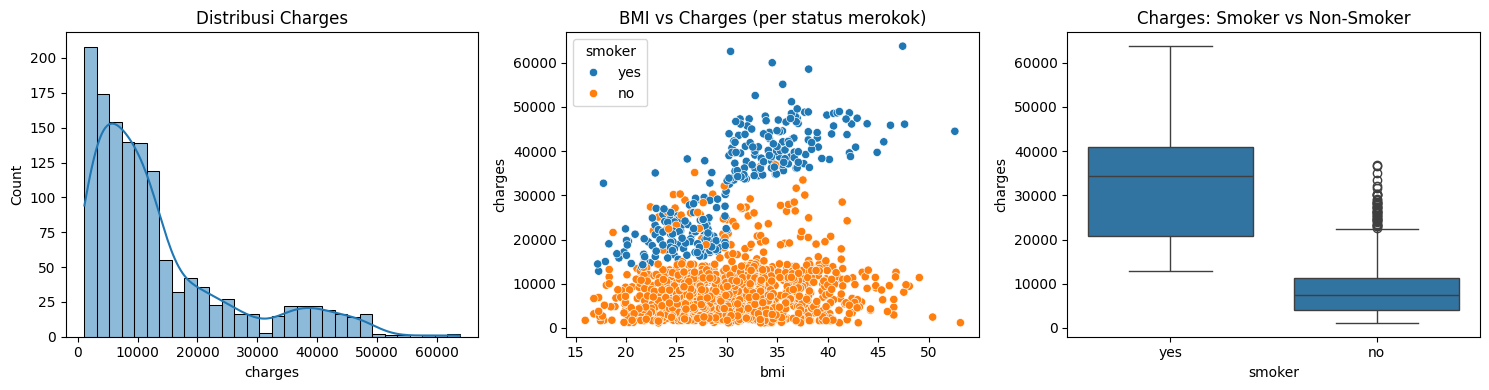

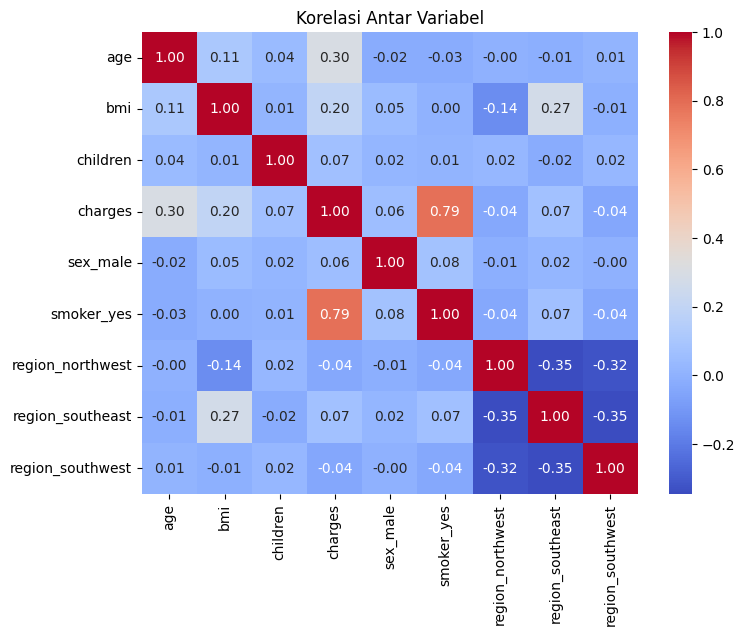

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi target, hubungan bmi-charges per status merokok, dan boxplot smoker
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['charges'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi Charges')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', ax=axes[1])
axes[1].set_title('BMI vs Charges (per status merokok)')

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[2])
axes[2].set_title('Charges: Smoker vs Non-Smoker')
plt.tight_layout()
plt.show()

# Heatmap korelasi (pakai data yang sudah di-encode)
plt.figure(figsize=(8, 6))
sns.heatmap(df_enc.corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Korelasi Antar Variabel')
plt.show()

## No 2 — Split Data

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## No 3 — Feature Scaling

In [66]:
from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()

##4 & 5 — Multiple Linear Regression: Training & Prediksi

In [71]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

##No 6 — Evaluasi Linear Regression

In [68]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("R-squared:", r2_lr)
print("MSE:", mse_lr)
print("MAE:", mae_lr)

R-squared: 0.7835929767120724
MSE: 33596915.85136145
MAE: 4181.19447375365


##No 7 — SVR + Hyperparameter Tuning

In [69]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train_scaled)
y_pred_svr_scaled = svr.predict(X_test_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).ravel()

In [70]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.5]
}
grid = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train_scaled)

best_svr = grid.best_estimator_
y_pred_best_scaled = best_svr.predict(X_test_scaled)
y_pred_best = scaler_y.inverse_transform(y_pred_best_scaled.reshape(-1, 1)).ravel()

In [72]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("=== SVR Default ===")
print("R-squared:", r2_score(y_test, y_pred_svr))
print("MSE:", mean_squared_error(y_test, y_pred_svr))
print("MAE:", mean_absolute_error(y_test, y_pred_svr))

print("\n=== SVR Tuned ===")
print("Best params:", grid.best_params_)
print("R-squared:", r2_score(y_test, y_pred_best))
print("MSE:", mean_squared_error(y_test, y_pred_best))
print("MAE:", mean_absolute_error(y_test, y_pred_best))

=== SVR Default ===
R-squared: 0.8622834992498352
MSE: 21380312.04694896
MAE: 2462.452729550437

=== SVR Tuned ===
Best params: {'C': 100, 'epsilon': 0.1, 'gamma': 0.01}
R-squared: 0.8689505549377426
MSE: 20345260.10861631
MAE: 2417.0260961236077


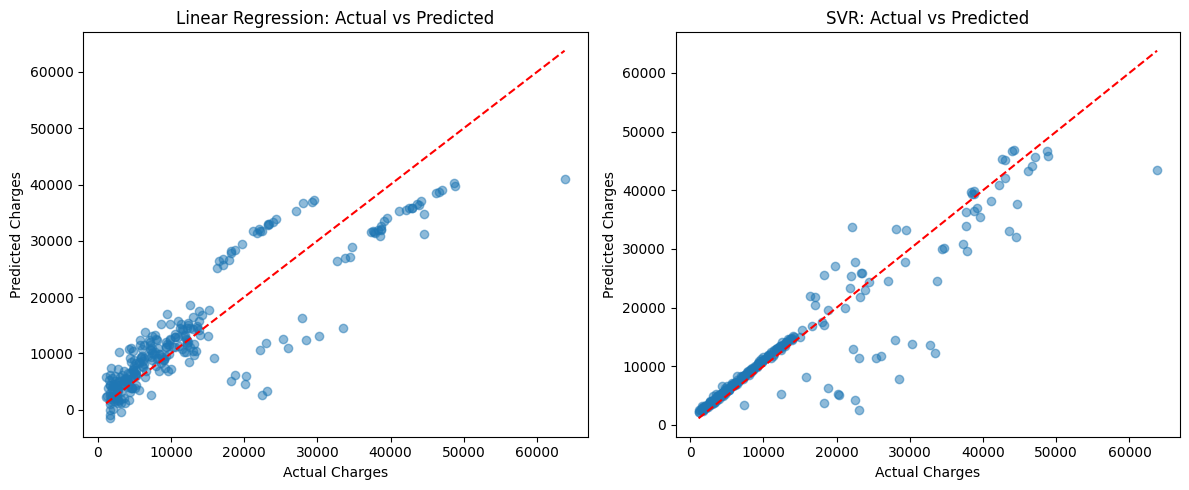

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual Charges'); axes[0].set_ylabel('Predicted Charges')
axes[0].set_title('Linear Regression: Actual vs Predicted')

axes[1].scatter(y_test, y_pred_svr, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual Charges'); axes[1].set_ylabel('Predicted Charges')
axes[1].set_title('SVR: Actual vs Predicted')

plt.tight_layout()
plt.show()

Perbandingan Kinerja Model

Model Support Vector Regression (SVR) dengan kernel RBF terbukti lebih akurat dibandingkan Multiple Linear Regression (MLR) dalam memprediksi biaya medis. Setelah proses hyperparameter tuning (parameter C=100, epsilon=0.1, gamma=0.01), SVR mencapai nilai R-squared sebesar 0,869 dengan Mean Absolute Error (MAE) 2.417. Sebagai perbandingan, MLR memiliki tingkat akurasi yang lebih rendah dengan R-squared 0,784 dan MAE 4.181.

Kesesuaian Model terhadap Karakteristik Data

Perbedaan performa ini disebabkan oleh ketidakmampuan model MLR dalam menangkap hubungan non-linier pada data. Hubungan antara metrik Body Mass Index (BMI) dan biaya medis sangat dipengaruhi oleh status merokok. Kenaikan BMI pada perokok memicu lonjakan biaya yang jauh lebih ekstrem dibandingkan kelompok non-perokok. Model SVR lebih efektif karena mampu mengakomodasi interaksi variabel yang kompleks dan non-linier tersebut.

Signifikansi Prediktor

Berdasarkan analisis koefisien regresi linier dan heatmap korelasi, status merokok merupakan variabel yang paling dominan dalam menentukan besaran biaya medis. Pengaruh variabel ini jauh melampaui faktor-faktor lain di dalam dataset, seperti usia maupun BMI.

Batasan Analisis

Meskipun model SVR telah dioptimalkan, masih terdapat 13,1% variansi data (1 - R²) yang belum dapat dijelaskan oleh model. Hal ini mengindikasikan adanya probabilitas faktor eksternal di luar dataset yang memengaruhi biaya medis asuransi, seperti riwayat penyakit spesifik pasien, lingkungan, atau risiko pekerjaan.